# 梯度裁剪:clip_grad_norm_ 

In [ ]:
torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), max_norm=1.0)
self.optimizer.step()

- 这两行代码是深度学习（特别是强化学习 RL 和大语言模型训练）中防止模型崩溃的“终极安全网”。

在 RL 训练中，由于奖励信号（Reward）往往非常稀疏且方差极大，或者模型在长序列生成时累积误差，极易发生梯度爆炸（Exploding Gradients）。
- 如果不加干预，模型参数会在一次更新中发生剧烈变化，导致损失（Loss）瞬间变成 NaN，训练彻底崩溃。

下面我为你详细拆解这两行代码的底层逻辑、工作原理以及工程实践中的注意事项。

##  核心机制：按范数裁剪（By Norm Clipping）
<font color='red'>torch.nn.utils.clip_grad_norm_ 是 PyTorch 中最常用的梯度裁剪函数。</font>

- 它的核心思想是：
  - <font color='red'>不改变梯度的方向，只限制梯度的整体大小（L2 范数）。</font>


In [ ]:
梯度方向
    ↑
    │    原始梯度 (‖g‖=5.0)
    │      ↗
    │    /
    │  /
    │/  裁剪后梯度 (‖g‖=1.0)
    └────────→
    
只改变长度，不改变方向。
如果梯度太大，就按比例"缩回"到半径为 max_norm 的球内。

- 计算总范数：
  - 它会将模型中所有参数的梯度视为一个巨大的向量，计算这个向量的 L2 范数（<font color='red'>即所有梯度元素的平方和再开根号</font>）。


In [1]:
from IPython.display import Image

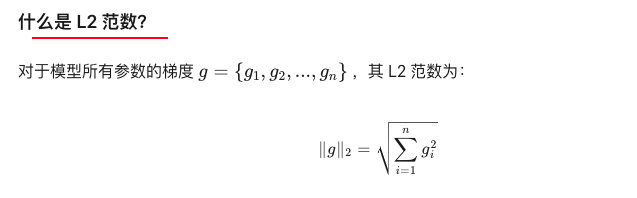

In [2]:
Image(filename='./Image/l2.png')

- 条件缩放：
  - 如果计算出的总范数大于设定的阈值（max_norm=1.0），<font color='red'>它会将所有参数的梯度等比例缩小</font>，**使得缩放后的总范数刚好等于 1.0。**
- 原地操作（In-place）：
  - 函数名末尾的下划线 _ 表示它会直接修改传入参数的 .grad 属性，不会创建新的张量，从而节省显存。

##  为什么必须放在 optimizer.step() 之前？
**这是工程实现中最容易犯的错误。** <font color='red'>这两行代码的顺序绝对不能颠倒：</font>

In [ ]:
# ✅ 正确顺序
loss.backward()
# 先裁剪
torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), max_norm=1.0) 
self.optimizer.step() # 再更新

# ❌ 错误顺序
loss.backward()
self.optimizer.step() # 已经用未裁剪的爆炸梯度更新了参数！
# 此时裁剪已经毫无意义
torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), max_norm=1.0) 

### 原因：
- optimizer.step() 会读取当前的梯度并更新权重。
  - **如果你在更新之后才裁剪，你裁剪的是已经被使用过的梯度（甚至可能是已经被优化器清零的梯度），对当前的参数更新没有任何影响。**

## max_norm=1.0 意味着什么？
max_norm 是一个极其关键的超参数，它决定了模型单次更新的最大步长：
- 如果设置太小（如 0.01）：
  - **梯度会被过度压缩**，模型学习极其缓慢，甚至可能因为步长太小而无法逃离局部最优，导致“停止学习”。
- 如果设置太大（如 100.0）：
  - 阈值形同虚设，当真正的梯度爆炸发生时，它无法提供足够的保护，模型依然会崩溃。
- 经验法则：
  - <font color='red'>在 LLM 的 RLHF/RLVR 训练中，1.0 是一个非常经典的默认起点。</font>
    - 许多主流框架（如 TRL、OpenRLHF）默认都使用 1.0 或 0.5。

## 进阶：按范数裁剪 vs 按值裁剪

在 PyTorch 中，还有一个函数叫 clip_grad_value_，它们有本质区别：

| 特性 | `clip_grad_norm_` (<font color='red'>按范数</font>) | `clip_grad_value_` (**按值**) |
| :--- | :--- | :--- |
| 操作方式 | 限制所有梯度的总 L2 范数  $ \le N $  | 限制每个梯度元素的绝对值  $ \in [-V, V] $  |
| 梯度方向 | <font color='red'>完全保留原始梯度方向</font> | <font color='blue'>可能扭曲梯度方向（因为个别元素被强行截断）</font> |
| 适用场景 | 绝大多数深度学习、RLHF 训练 | 发现个别极端异常梯度时的特殊处理 |

## 工程监控建议
<font color='red'>在实际训练大模型时，建议不要“盲裁”，而是监控裁剪的触发频率。</font>

你可以获取裁剪前的真实范数：

In [ ]:
# 获取裁剪前的总范数
total_norm = torch.nn.utils.clip_grad_norm_(
    self.policy_model.parameters(), 
    max_norm=1.0, 
    error_if_nonfinite=False # 防止出现 NaN 时直接报错中断
)

# 如果 total_norm 经常远大于 1.0，说明你的学习率可能太大，
# 或者 Reward Model 存在严重问题
if total_norm > 1.0:
    print(f"Warning: Gradient clipped from {total_norm:.2f} to 1.0")

## 为什么在 RL 中"特别重要"？
梯度裁剪在监督学习（**SL**）中也有用，但在 RL 中几乎是刚需。原因如下：
###  重要性采样比率的不稳定性
PPO 的核心是比率 $ρ= \frac{π_{new}}{π_old}$ 。如果策略更新幅度稍大，某些 token 的概率可能从 0.01 跳到 0.99，导致：

- ρ  极大（如 100）
- 优势值 A  可能也很大（如 +10）
- 梯度 ∇logπ⋅ρ⋅A  可能爆炸
在 **SL** 中，损失通常是 MSE 或交叉熵，梯度有界；在 RL 中，梯度可能因 ρ×A  的乘积而**无界增长**。

###  优势估计的噪声
- 优势函数 $\hat{A_t}$ 通常通过 GAE（Generalized Advantage Estimation）计算，本身带有**高方差**。
  - <font color='red'>如果某个 batch 碰巧采样到极端优势值（如一个 prompt 的奖励是 +1，另一个是 -1，但 batch 很小），梯度会被这些噪声"拉偏"。</font>
  
###  策略空间的非凸性
- LLM 的策略空间是高维且非凸的。一次大的梯度步可能让模型从"合理策略"跳到"完全崩溃的策略"
  - 例如，模型突然学会只输出某个固定 token，导致后续所有采样的多样性丧失（模式崩溃）。

###  自举（Bootstrapping）的反馈循环
RL 的数据是由当前策略自己生成的。如果一次更新让策略变"坏"，下一步生成的数据质量下降，价值函数估计更不准，梯度更噪声，形成恶性循环。梯度裁剪打破了这个正反馈。


## 两个"Clip"的区别（极易混淆）
在 PPO 代码中你会看到两个 clip，它们是完全不同的东西：

|          | `torch.nn.utils.clip_grad_norm_` | `torch.clamp(ratio, 1-ε, 1+ε)`         |
| :------- | :------------------------------- | :------------------------------------- |
| **中文**   | 梯度裁剪                             | PPO 的比率裁剪（Clipped Surrogate Objective） |
| **位置**   | 反向传播<font color='red'>**之后**</font>，优化器 step **之前**       | 前向传播<font color='red'>**之中**</font>，计算 loss **之时**              |
| **对象**   | 参数的**梯度** $g$                    | 重要性采样**比率** $\rho$                     |
| **目的**   | 防止梯度爆炸，稳定优化                      | 限制策略更新幅度，防止策略突变                        |
| **数学**   | $\|g\|_2 \leq \text{max\_norm}$  | $\rho \in [0.8, 1.2]$（若 ε=0.2）         |
| **是否必须** | <font color='red'>强烈建议，尤其在 RL 中 </font>                   | PPO 算法的核心定义                            |

### 关系：
- PPO 的 ratio clip 限制了 loss 的"理论上限"，但数值计算中梯度仍可能因浮点精度、极端样本等原因爆炸，所以两个 clip 都要用，互为保险。

## 如果不裁剪会怎样？
### 场景：某一步的 ratio 计算出错
假设模型对某个 token 的概率估计出现数值问题：
- log_prob_new = -0.01
- log_prob_old = -100.0（旧策略认为这个 token 几乎不可能）
- log_diff = 99.99
- seq_log_ratio = 99.99（假设序列只有一个 token）
- $ratio = e^{99.99} \approx 10^{43}$

### 梯度爆炸链式反应
1. ratio × advantage **变成天文数字**
2. <font color='red'>反向传播时，这个巨大的值沿着 Transformer 各层传播</font>
3. 某些层的梯度范数达到 $10^6 $. 甚至更高
4. <font color='red'>optimizer.step() 用这个大梯度更新权重</font>
5. **模型参数瞬间偏移到荒谬值**
6. 下一步生成全是乱码，训练彻底崩溃

### 裁剪后的保护
clip_grad_norm_ 在 step 前检查到总梯度范数异常（如 $10^6$），将其缩放到 1.0：
- 参数更新量 = lr × 1.0（假设 lr=1e-5，则更新量为 1e-5）
- 模型不会跳崖，只是"迈了一小步"
- 虽然这一步可能不是最优方向，但至少训练还活着

In [ ]:
grads = [2.0, 3.0, 4.0]  # 三个参数的梯度

# L2 范数
norm = sqrt(2² + 3² + 4²) = sqrt(4 + 9 + 16) = sqrt(29) ≈ 5.385

# max_norm = 1.0，需要缩放
scale = 1.0 / 5.385 ≈ 0.186

# 裁剪后的梯度
clipped_grads = [2.0×0.186, 3.0×0.186, 4.0×0.186] ≈ [0.372, 0.557, 0.743]

# 验证范数
sqrt(0.372² + 0.557² + 0.743²) ≈ 1.0 ✓

## 总结：
- 这两行代码是 RL 训练的“安全带”。clip_grad_norm_ 确保了无论环境给出多么极端的奖励反馈，模型的参数更新都会被限制在一个安全的物理边界内，从而保证了长达数万步训练的数值稳定性。

# 梯度消失

如果说梯度爆炸（Gradient Explosion）是 RL 训练中的“车祸”，那么梯度消失（Gradient Vanishing）就是“慢性缺氧”。
- 它通常不会让 Loss 瞬间变成 NaN 导致训练直接崩溃，<font color='red'>而是让模型在不知不觉中“停止学习”（Stagnation），或者只能学到非常局部的、肤浅的模式。</font>

**在 RL（尤其是基于 LLM 的 RLHF/GRPO）训练中，梯度消失的成因比传统的监督学习更复杂。**下面我为你深度拆解其成因与检测手段。

## 一、 RL 训练中梯度消失的核心成因

### 奖励信号的极度稀疏（Sparse Rewards）
<font color='red'>这是 RL 最根本的痛点。</font>在长文本生成中，模型可能生成了 1000 个 Token，**但 Reward Model 只在最后给出一个标量分数（比如 +1 或 -1）。**
- 机制：
  - 根据策略梯度定理（Policy Gradient Theorem），梯度是∇J=E[∇logπ(a∣s)⋅R] 。如果 R 的方差极大，且正负奖励相互抵消，或者绝大多数序列的 R 都是 0（比如代码跑不通直接给 0 分），**那么经过大量样本平均后，期望梯度 
E[…] 就会趋近于 0。**
- 结果：
  - <font color='red'>模型发现“无论我怎么改参数，平均收益都不变”，于是梯度消失，停止更新。</font>
  
### 重要性采样比率（Ratio）的极端化
在 PPO/GSPO 中，<font color='red'>梯度会被重要性采样比率 $r(\theta) =\frac{ \pi_{new}}{\pi_{old}}$缩放。</font>

- 机制：如果新模型对某个 Token 的预测概率变得极低（比如从 0.5 掉到了 0.001），而旧模型是 0.5，那么 Ratio 会非常小。虽然梯度公式里有 logπ ，但在实际计算 Surrogate Loss 时，**极小的 Ratio 会导致梯度信号被极度压缩。**
- 结果：模型在生成某些特定词时“失去自信”，梯度无法传回这些词，导致模型只会重复生成那几个高概率的“安全词”（Mode Collapse）。

### 长序列与 KL 散度惩罚的“双重绞杀”
- 长序列：
  - **在长文本中，为了维持概率和为 1，每个 Token 的概率必然很小**。 logπ 会变成很大的负数，导致数值计算中的梯度极小。
- KL 惩罚：
  - 为了防止模型偏离 Reference Model 太远，我们通常会加上 KL 惩罚。如果 KL 的系数 β 设置过大，KL 的梯度会完全主导策略梯度。此时，模型更新的唯一动力变成了“尽量和旧模型一模一样”，而不是“去拿高奖励”。
- 结果：
  - <font color='red'>策略梯度被 KL 梯度淹没，有效梯度消失。</font>
  
###  优势函数（Advantage）的归一化陷阱
在 GRPO 中，我们会对一组回复的奖励做归一化： $A = \frac{R−μ}{σ}$

- 机制：
  - 如果模型在这一轮生成的所有回复质量都极其糟糕（比如全是不及格的代码），那么这组回复的奖励**方差 σ** 会非常小。此时除以 σ 虽然放大了数值，但如果所有 R 都等于 μ ，那么 A 就全是 0。
- 结果：
  - 没有相对优势，就没有梯度方向。

## 如何精准检测梯度消失？
梯度消失不能只看 Loss 曲线（<font color='blue'>因为 Loss 可能很平稳，但模型已经不学了</font>）。

你需要监控以下几个核心指标：

###  监控梯度范数（Gradient Norm）
**这是最直接的指标。**  在 optimizer.step() 之前，打印梯度的 L2 范数。

In [ ]:
# 计算梯度总范数
total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float('inf'))
print(f"Gradient Norm: {total_norm.item():.6f}")

- 健康状态：梯度范数在 $10^{-4}$到$10^{-2}$之间波动。
- 危险信号：<font color='red'>梯度范数持续低于 $10^{−6}$，甚至变成 0.0。</font>

### 监控策略更新幅度（KL Divergence / Policy Delta）
**如果梯度消失了，模型的参数就不会更新。** <font color='red'>你可以计算新旧模型参数的差异，或者新旧策略的 KL 散度。</font>

In [ ]:
# 计算当前策略与初始策略（或上一步策略）的 KL 散度
kl_div = (log_probs - ref_log_probs).exp() - (log_probs - ref_log_probs) - 1
avg_kl = kl_div.mean().item()

#### 危险信号：avg_kl 长期停滞在极小的值（如 $<10^{−5}$），说明模型已经“僵死”，不再探索新策略。

###  监控奖励的方差（Reward Variance）
<font color='red'>这是诊断“稀疏奖励导致梯度消失”的利器。</font>
- 危险信号：在一个 Batch 或一个 Group 内，所有样本的 Reward 完全一样（例如全是 0，或全是 1）。此时 Advantage 为 0，梯度必然消失。

###  监控生成文本的多样性（Entropy / Unique N-grams）
梯度消失往往伴随着模式坍塌（Mode Collapse）。
- 危险信号：**模型生成的回复开始高度重复**（例如无限输出 "I don't know"），或者生成文本的 Token 级熵（Entropy）急剧下降并贴底。<font color='red'>这说明模型放弃了探索，只保留了局部最优的梯度。</font>

##  发现梯度消失后的“急救措施”
如果你通过上述手段确诊了梯度消失，可以尝试以下操作：
1. **降低 KL 惩罚系数 ( β )：**
  - 如果 KL 主导了梯度，立刻减小 β ，让策略梯度重新拿回话语权。
2. **调整学习率（Learning Rate Warmup/Decay）：**
  - 有时候梯度消失是因为模型陷入了极其平坦的 Loss 盆地。适当增大学习率或重启 Warmup，可以帮模型“跳出”平坦区。
3. **引入 Entropy Bonus（熵奖励）：**
  - 在 Loss 中加上 $−β_{entropy}⋅H(π)$ 。这会强制鼓励模型保持较高的输出熵（即保持“好奇心”），防止概率坍缩到单个 Token 上。
4. **优化奖励设计（Reward Shaping）：**
  - 如果是稀疏奖励导致的，考虑引入<font color='red'>过程奖励（Process Reward Model, PRM）</font>，在中间步骤给予微小的奖励信号，保持梯度的持续流动。

### 总结来说，
- 梯度爆炸是“<font color='red'>急性病</font>”，靠 clip_grad_norm 就能救；
- 而梯度消失是“<font color='red'>慢性病</font>”，**需要结合梯度范数、KL 散度、奖励方差进行综合诊断，并通过调整超参数或奖励机制来慢慢调理。**
